# Does a Solver listen to its Critic?

```
Gemma answers (A1)  →  Qwen reviews it  →  Gemma answers again (A2)
         ↑ activation saved                          ↑ activation saved
```

Can features in Gemma's activation tell us whether it will adopt the Critic, keep A1, or change its answer? And if we clamp such a feature, does the behaviour change?

*Words used below.* **Episode**: one question's A1 → review → A2. **Activation**: the numbers inside Gemma at one layer, saved just before it answers. **SAE**: a sparse autoencoder, a small model that rewrites an activation as a few named features. **Probe**: a simple classifier from those features to what Gemma did. **Clamp**: force one feature to a fixed value while Gemma answers, to see if the behaviour changes.

## The story so far

| | What we did | What we saw | What we decided |
|---|---|---|---|
| 1. Proposal | one model: Gemma plays both Solver and Critic; three kinds of feedback: natural, the correct answer handed to the Critic, a wrong answer handed to the Critic | | |
| 2. First run, 200 questions | one model, all three kinds of feedback | natural: Gemma reviewing itself repeated its own answer in 179 of 183 reviews, so A2 almost never changed; the two "answer handed to the Critic" kinds: the prompt gave away that an answer had been handed over, and the wrong answers often did not fit the question | fix the prompts; try a second model as Critic |
| 3. One model vs two, 100 questions | same questions and same Gemma answers, reviewed once by Gemma (one model) and once by Qwen (two models) | Gemma reviewing itself repeated the answer 96% of the time; Qwen 42%; Gemma changed its answer 20% vs 52%; same accuracy | switch to two models: Gemma stays the Solver, Qwen becomes the Critic |
| 4. Scope | | natural feedback from Qwen already gives adopt / keep / change variation | natural feedback only; the two "answer handed over" kinds kept for later |
| 5. Production run | 22,332 questions, one episode each, activations saved at layers 8, 17, 25, 33 | Gemma mostly follows Qwen when they disagree | label what Gemma did in every episode |
| 6. Question groups | | which group (train / validation / test / intervention) a question was in depended on the file it sat in, and two runs disagreed | one fixed list by question id; saved activations regrouped, nothing re-collected |
| 7. Now | choosing the layer, training the SAE | | then probe → one test evaluation → clamp |

The sections below show the evidence for each row.

## Rows 2 and 3: why we switched from one model to two

The same 100 questions and the same Gemma answers, reviewed by Gemma itself (one model) and by Qwen (two models). Then the same three questions under each:

In [1]:
import json, os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 320)
ARTIFACTS = Path(os.environ.get("MAS_SAE_ARTIFACTS", "~/capstone-artifacts")).expanduser()
PACKAGE, FULL_RUN, EXPORT = ARTIFACTS / "behavior_v011_split80_10_10_20261006", ARTIFACTS / "natural_4b_full", ARTIFACTS / "natural_4b_partitioned"
INPUTS = Path("experiment_analysis_inputs")

labels = pd.read_csv(PACKAGE / "labels.csv")
manifest = pd.read_csv(PACKAGE / "split_manifest.csv")

def read_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]

FIELDS = [("Question", "question"), ("Solver A1", "solver_attempt_1"), ("Critic feedback", "critic_feedback"), ("Solver A2", "solver_attempt_2")]
def episode_table(episodes, columns, extra=None):
    rows = {name: [e[field] for e in episodes] for name, field in FIELDS}
    rows.update(extra or {})
    return pd.DataFrame(rows, index=columns).T

# What the 100-question pilot showed (same questions, same Solver answers, two Critics).
pilot = pd.read_csv(INPUTS / "critic_comparison_100q.csv").set_index("Stage")
display(pilot.loc[["Gemma one-step, 256 tokens", "Qwen one-step, 256 tokens"], ["Critic copied Solver", "Solver changed answer", "Final exact accuracy"]]
        .rename(index={"Gemma one-step, 256 tokens": "One model: Gemma reviews itself", "Qwen one-step, 256 tokens": "Two models: Qwen reviews Gemma"},
                columns={"Critic copied Solver": "Critic repeated Gemma", "Solver changed answer": "Gemma changed answer", "Final exact accuracy": "Accuracy"}))

# The same three questions: Gemma reviewing itself (one model), then Qwen reviewing Gemma (two models).
reviews = read_jsonl(INPUTS / "critic_comparison_example.jsonl")
gemma_reviews, qwen_reviews = reviews[0::2], reviews[1::2]
def outcome(r):
    if not r["solver_changed_answer"]:
        return "A2 unchanged"
    return "A2 adopts the Critic" if r["solver_attempt_2"].strip().lower() == str(r["critic_advocated_answer"]).strip().lower() else "A2 changed to another answer"
def side_by_side(rows, title):
    return episode_table(rows, [f"{title} {i}" for i in (1, 2, 3)],
                         extra={"Correct answer": [r["ground_truth"] for r in rows], "What happened": [outcome(r) for r in rows]})
display(side_by_side(gemma_reviews, "One model (Gemma reviews itself)"))
side_by_side(qwen_reviews, "Two models (Qwen reviews Gemma)")

,Critic repeated Gemma,Gemma changed answer,Accuracy
Stage,,,
One model: Gemma reviews itself,94/98 (95.9%),20/100 (20.0%),18/100 (18.0%)
Two models: Qwen reviews Gemma,37/89 (41.6%),52/100 (52.0%),19/100 (19.0%)


,One model (Gemma reviews itself) 1,One model (Gemma reviews itself) 2,One model (Gemma reviews itself) 3
Question,In what year did the conflict the Battle of Khafji was part of start?,Where did Mok Kwai-lan's spouse die?,When is the last time Auburn won in the city where Shaw Center for the Arts is located?
Solver A1,1991,"November 3, 1982",2006
Critic feedback,"The reviewer agrees with your previous answer. The reviewer advocates this answer: 1991 Reviewer explanation: The text states that the Battle of Khafji took place ‘from 29 January to 1 February 1991’ as part of the Persian Gulf War, which began in August 1990.","The reviewer agrees with your previous answer. The reviewer advocates this answer: November 3, 1982 Reviewer explanation: Paragraph 12 states: ""Mok Kwai-lan (; October 15, 1892 – November 3, 1982) was the fourth spouse of Lingnan martial arts grandmaster Wong Fei-hung.""","The reviewer agrees with your previous answer. The reviewer advocates this answer: 2006 Reviewer explanation: The text states that in 2006, Auburn won against LSU at Baton Rouge, where the Shaw Center for the Arts is located. This is the last time Auburn won in that city according to the provided information."
Solver A2,1991,"November 3, 1982",2006
Correct answer,2 August 1990,Canton,1999
What happened,A2 unchanged,A2 unchanged,A2 unchanged


,Two models (Qwen reviews Gemma) 1,Two models (Qwen reviews Gemma) 2,Two models (Qwen reviews Gemma) 3
Question,In what year did the conflict the Battle of Khafji was part of start?,Where did Mok Kwai-lan's spouse die?,When is the last time Auburn won in the city where Shaw Center for the Arts is located?
Solver A1,1991,"November 3, 1982",2006
Critic feedback,"The reviewer disagrees with your previous answer. The reviewer advocates this answer: 1990 Reviewer explanation: The Battle of Khafji took place from 29 January to 1 February 1991, and it was part of the Persian Gulf War, which began in 1990 following Iraq's invasion of Kuwait. Therefore, the conflict started in 19...","The reviewer disagrees with your previous answer. The reviewer advocates this answer: Unknown Reviewer explanation: The proposed answer states that Mok Kwai-lan's spouse died on November 3, 1982. However, the text only states that Mok Kwai-lan was the fourth spouse of Wong Fei-hung, and provides no information abou...","The reviewer disagrees with your previous answer. The reviewer advocates this answer: 2014 Reviewer explanation: The Shaw Center for the Arts is located in Baton Rouge, Louisiana. From the provided text, the Auburn–LSU football rivalry results show that Auburn won in Baton Rouge in 2004 (34–10), 2005 (24–17), 2006 ..."
Solver A2,1990,Unknown,2014
Correct answer,2 August 1990,Canton,1999
What happened,A2 adopts the Critic,A2 adopts the Critic,A2 adopts the Critic


## Row 5: three real production episodes where Qwen disagreed with Gemma

In [2]:
full_train = read_jsonl(FULL_RUN / "results" / "train" / "interactions.jsonl")
by_q = labels.set_index("question_id")

def pick(response):
    candidates = [r for r in full_train
                  if by_q.loc[r["question_id"], "partition"] == "train" and by_q.loc[r["question_id"], "eligible_primary"]
                  and by_q.loc[r["question_id"], "solver_response"] == response and r["critic_feedback"].startswith("The reviewer disagrees")]
    return min(candidates, key=lambda r: sum(len(str(r[f])) for _, f in FIELDS))

examples = {"adopted_critic": pick("adopted_critic"), "retained_a1": pick("retained_a1"), "third_answer": pick("third_answer")}
episode_table(list(examples.values()), ["Adopts the Critic", "Keeps A1", "Third answer"],
              extra={"Correct answer": [e["ground_truth"] for e in examples.values()], "Label": list(examples)})

,Adopts the Critic,Keeps A1,Third answer
Question,What year did the employer of William Sharp die?,In what county would you find Carpenter which shares a state with Cold Brook Dam?,How many states are in the country where Sandamu is located?
Solver A1,1820,Clark County,Eight
Critic feedback,The reviewer disagrees with your previous answer. The reviewer advocates this answer: 1810 Reviewer explanation: The text states that William Sharp died on 17 March 1810. The proposed answer of 1820 is incorrect.,"The reviewer disagrees with your previous answer. The reviewer advocates this answer: Fall River County Reviewer explanation: Carpenter is located in Clark County, South Dakota, and the Cold Brook Dam is in Fall River County, South Dakota. Both are in the same state, South Dakota. However, the question asks for the...","The reviewer disagrees with your previous answer. The reviewer advocates this answer: 1 Reviewer explanation: Sandamu is located in Katsina State, Nigeria. Nigeria has 36 states and one Federal Capital Territory. Therefore, the country where Sandamu is located has 36 states, not eight. The proposed answer of 'Eight..."
Solver A2,1810,Clark County,36
Correct answer,1820,Clark County,thirty-six
Label,adopted_critic,retained_a1,third_answer


Labels say what Gemma did, not whether it was right. Hand check in progress.

| Label | Meaning |
|---|---|
| `adopted_critic` | A2 is the Critic's answer |
| `retained_a1` | A2 is still A1 |
| `third_answer` | A2 is neither A1 nor the Critic's answer |
| `unchanged_same_position` | A1, Critic and A2 already agreed |
| `non_answer` | A2 refuses or says it cannot tell |
| `produced_answer` | the Critic gave no answer; A2 did |
| `unresolved` | A2 is missing or hedged; the rules cannot tell |

,all episodes,Critic disagreed
solver_response,,
adopted_critic,7234,5606
non_answer,4090,0
produced_answer,1130,0
retained_a1,1465,167
third_answer,661,495
unchanged_same_position,6645,0
unresolved,1107,0


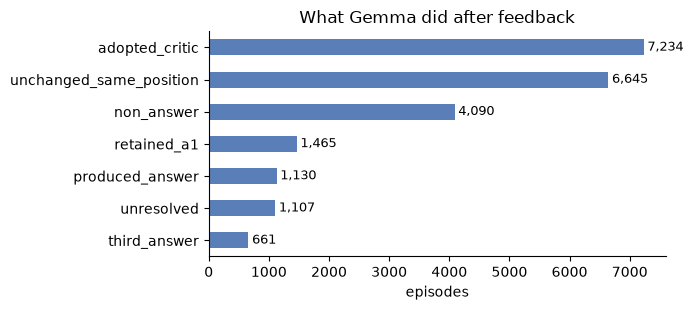

In [3]:
counts = labels["solver_response"].value_counts()
disagreed = labels[labels["eligible_primary"]]["solver_response"].value_counts()
display(pd.DataFrame({"all episodes": counts, "Critic disagreed": disagreed}).fillna(0).astype(int))

fig, ax = plt.subplots(figsize=(7, 3.2))
counts.sort_values().plot.barh(ax=ax, color="#5a7fb8")
ax.set_xlabel("episodes"); ax.set_ylabel(""); ax.set_title("What Gemma did after feedback")
for i, v in enumerate(counts.sort_values()):
    ax.text(v + 60, i, f"{v:,}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

When Qwen disagreed with Gemma: 5,606 adopted, 167 kept A1, 495 third answer.

## Row 6: the four question groups

In [4]:
partitions = manifest["partition"].value_counts().reindex(["train", "validation", "test", "intervention"])
exported = json.loads((EXPORT / "results" / "collection" / "natural_4b_partitioned" / "export_summary.json").read_text())["partition_counts"]
display(pd.DataFrame({
    "questions": partitions,
    "taken from": ["MuSiQue train (80%)", "MuSiQue validation (all)", "MuSiQue train (10%)", "MuSiQue train (10%)"],
    "used for": ["fit", "choose", "evaluate once", "clamp"],
    "activation rows per layer": [2 * exported[p]["questions"] if exported[p]["rows"] else "none; ids kept aside" for p in partitions.index]}))

import torch
assert len(manifest) == 22_332 and manifest["question_id"].is_unique
assert partitions.to_dict() == {"train": 15_936, "validation": 2_413, "test": 1_992, "intervention": 1_991}
assert (manifest.loc[manifest["source_split"] == "validation", "partition"] == "validation").all()
for part in ("train", "validation", "test"):
    rows = torch.load(EXPORT / "data" / "activations" / "natural_4b_partitioned" / "layer_33" / f"{part}.pt", mmap=True, weights_only=True).shape[0]
    assert rows == 2 * partitions[part]
print("checked: 22,332 questions, each in one group; file rows = 2 × questions")

,questions,taken from,used for,activation rows per layer
partition,,,,
train,15936,MuSiQue train (80%),fit,31872
validation,2413,MuSiQue validation (all),choose,4826
test,1992,MuSiQue train (10%),evaluate once,3984
intervention,1991,MuSiQue train (10%),clamp,none; ids kept aside


checked: 22,332 questions, each in one group; file rows = 2 × questions


## Row 7: what is left

| | |
|---|---|
| Choose the layer (fit on train, compare on validation) | in progress |
| Train the SAE (fit on train, pick the best version on validation) | in progress |
| Probe: SAE features → behaviour | pending |
| Fix the layer, SAE, probe and feature, then evaluate once on test | pending |
| Clamp a feature on the intervention questions; does A2 change? | pending |

---
*Other fields in the label file. `feedback_type`: what the Critic gave (an answer, a refusal, a rejection of the question itself, or unclear). `conflict_status`: whether A1 and the Critic's answer differed.*